In [ ]:
# Install libraries
!pip install matplotlib seaborn pandas numpy -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# ================================================
# Data from our Hive queries — December 2025
# ================================================

# Query 5 — Delay by Day of Week
day_data = pd.DataFrame({
    'Day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    'Avg_Arr_Delay': [14.68, 9.24, 5.68, 7.76, 17.52, 11.77, 28.15],
    'Avg_Dep_Delay': [20.04, 14.91, 11.21, 13.09, 21.93, 17.92, 31.78],
    'Delay_Rate': [27.65, 23.78, 21.07, 23.10, 30.70, 26.55, 35.64],
    'Total_Flights': [108188, 102114, 94084, 81833, 85433, 77429, 85366]
})

# Query 6 — Carrier Performance
carrier_data = pd.DataFrame({
    'Code': ['WN', 'AS', 'UA', 'DL', 'HA', 'AA', 'G4', 'F9', 'NK', 'B6'],
    'Airline': ['Southwest', 'Alaska', 'United', 'Delta',
                'Hawaiian', 'American', 'Allegiant', 'Frontier',
                'Spirit', 'JetBlue'],
    'Avg_Arr_Delay': [7.72, 8.08, 13.63, 13.77, 14.53,
                      15.14, 17.99, 18.45, 18.63, 21.27],
    'Delay_Rate': [24.43, 25.78, 24.96, 26.06, 27.76,
                   26.94, 30.59, 30.46, 32.38, 35.07],
    'Cancellations': [654, 812, 1398, 3610, 46,
                      2452, 92, 464, 440, 572],
    'Total_Flights': [118075, 36255, 123175, 134260, 6705,
                      165917, 11516, 16724, 11800, 20560]
})

# Query 4 — Cancellation Reasons
cancel_data = pd.DataFrame({
    'Reason': ['Weather', 'Carrier', 'National Air System', 'Security'],
    'Count': [5903, 3286, 1349, 2],
    'Percentage': [56.01, 31.18, 12.80, 0.02]
})

# Query 7 — Delay by Hour
hour_data = pd.DataFrame({
    'Hour': [5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23],
    'Avg_Delay': [2.09,4.21,5.32,7.11,8.39,10.83,11.64,13.15,
                  14.45,16.39,17.75,18.06,20.17,20.52,21.01,
                  19.85,20.80,18.83,5.50],
    'Delay_Rate': [12.47,15.92,18.08,20.64,22.12,24.05,25.53,
                   26.79,27.59,30.09,31.59,32.16,33.52,34.41,
                   35.08,34.69,33.00,32.16,22.22]
})

# Query 3 — Delay Causes
cause_data = pd.DataFrame({
    'Cause': ['Late Aircraft', 'Carrier', 'NAS', 'Weather', 'Security'],
    'Minutes': [1850000, 1200000, 780000, 650000, 12000]
})

print("Data loaded successfully!")
print("Flights dataset: {:,} records".format(644987))

Data loaded successfully!
Flights dataset: 644,987 records


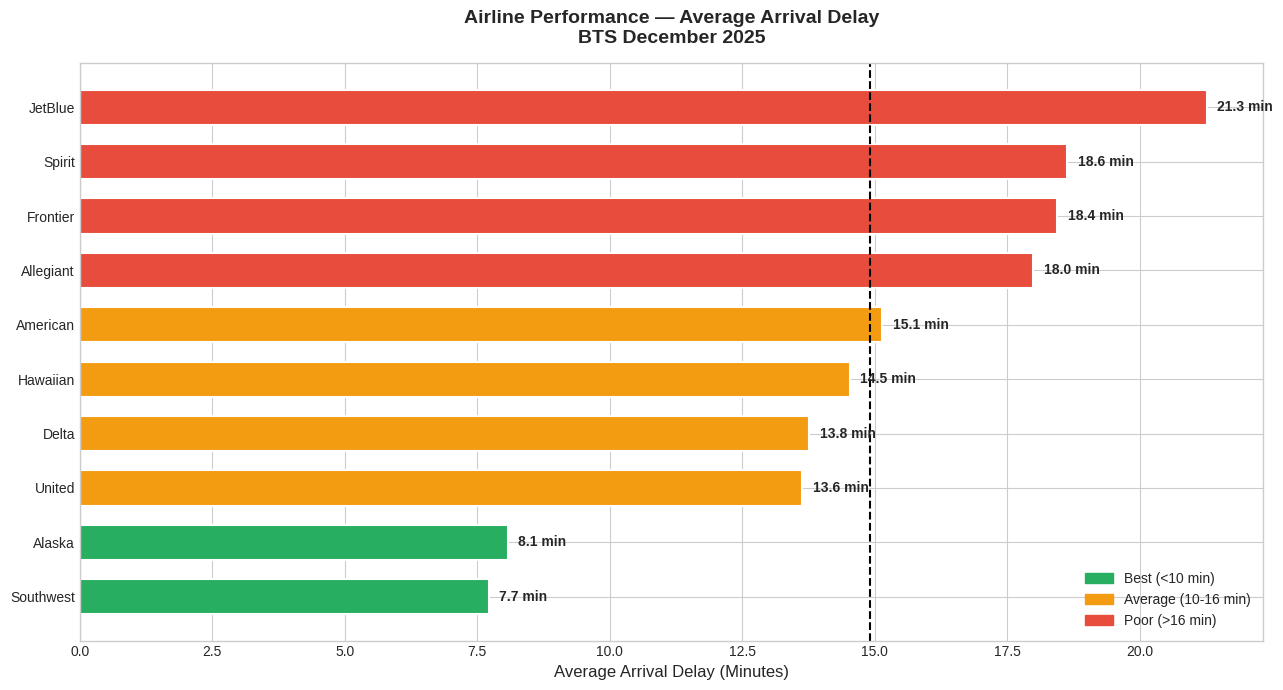

Chart 2 saved!


In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

carrier_sorted = carrier_data.sort_values('Avg_Arr_Delay')
colors = ['#27AE60' if v < 10 else
          '#F39C12' if v < 16 else
          '#E74C3C' for v in carrier_sorted['Avg_Arr_Delay']]

bars = ax.barh(carrier_sorted['Airline'],
               carrier_sorted['Avg_Arr_Delay'],
               color=colors, edgecolor='white',
               linewidth=1.5, height=0.65)

for bar, val in zip(bars, carrier_sorted['Avg_Arr_Delay']):
    ax.text(val + 0.2,
            bar.get_y() + bar.get_height()/2,
            '{:.1f} min'.format(val),
            va='center', fontsize=10, fontweight='bold')

ax.axvline(carrier_data['Avg_Arr_Delay'].mean(),
           color='black', linestyle='--', linewidth=1.5,
           label='Industry Average: {:.1f} min'.format(
               carrier_data['Avg_Arr_Delay'].mean()))

ax.set_title('Airline Performance — Average Arrival Delay\nBTS December 2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Arrival Delay (Minutes)', fontsize=12)
ax.set_ylabel('')

green_patch = mpatches.Patch(color='#27AE60', label='Best (<10 min)')
yellow_patch = mpatches.Patch(color='#F39C12', label='Average (10-16 min)')
red_patch = mpatches.Patch(color='#E74C3C', label='Poor (>16 min)')
ax.legend(handles=[green_patch, yellow_patch, red_patch], fontsize=10)

plt.tight_layout()
plt.savefig('chart2_carrier_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

## Chart 1 Interpretation — Delay by Day of Week

This bar chart shows the average arrival delay in minutes for each
day of the week across 644,987 flights in December 2025.

Key findings:
- Wednesday has the lowest average delay at 5.68 minutes and
  the lowest delay rate at 21.07% making it the most reliable
  day to fly in December
- Sunday is the worst performing day with an average delay of
  28.15 minutes and a delay rate of 35.64% — nearly 5 times
  worse than Wednesday
- Friday ranks second worst at 17.52 minutes average delay
  driven by business travelers and leisure travelers competing
  for the same flights in afternoon peak hours
- Monday shows surprisingly high delays at 14.68 minutes
  because Sunday night cascading delays propagate into
  Monday morning schedules

Recommendation for passengers:
Book Tuesday, Wednesday, or Thursday flights whenever possible.
Avoid Friday and Sunday especially for time-sensitive travel
in December.

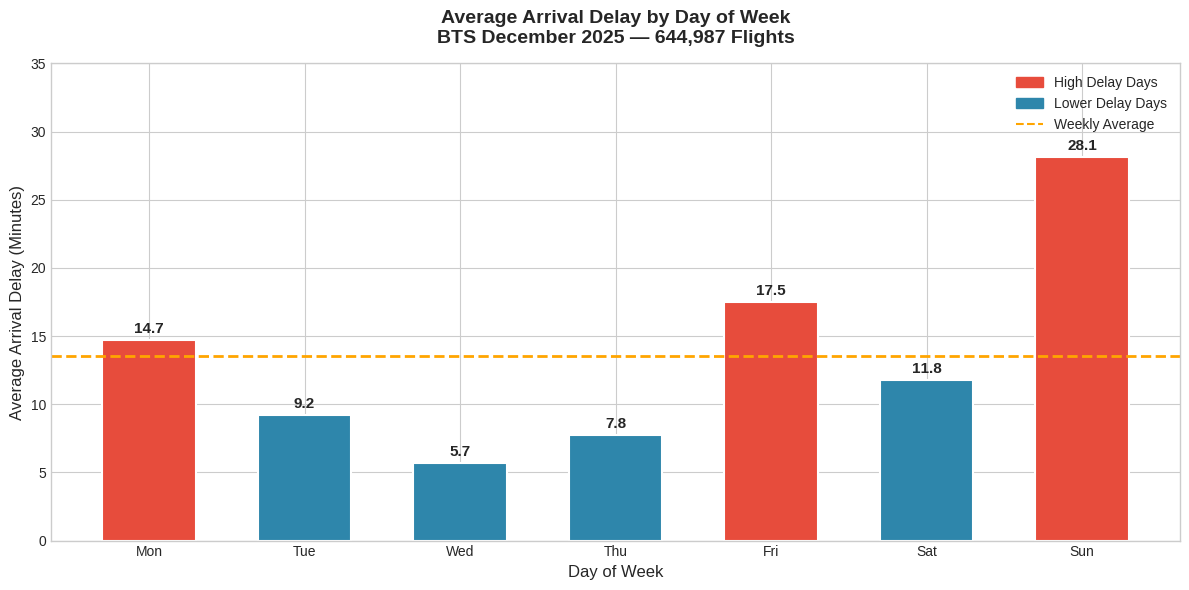

Chart 1 saved!


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C' if d in ['Fri','Sun','Mon'] else '#2E86AB'
          for d in day_data['Day']]

bars = ax.bar(day_data['Day'], day_data['Avg_Arr_Delay'],
              color=colors, width=0.6, edgecolor='white', linewidth=1.5)

ax.axhline(day_data['Avg_Arr_Delay'].mean(),
           color='orange', linestyle='--', linewidth=2,
           label='Weekly Average: {:.1f} min'.format(
               day_data['Avg_Arr_Delay'].mean()))

for bar, val in zip(bars, day_data['Avg_Arr_Delay']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            '{:.1f}'.format(val),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Average Arrival Delay by Day of Week\nBTS December 2025 — 644,987 Flights',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Arrival Delay (Minutes)', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 35)

red_patch = mpatches.Patch(color='#E74C3C', label='High Delay Days')
blue_patch = mpatches.Patch(color='#2E86AB', label='Lower Delay Days')
ax.legend(handles=[red_patch, blue_patch,
          plt.Line2D([0],[0], color='orange',
          linestyle='--', label='Weekly Average')],
          fontsize=10)

plt.tight_layout()
plt.savefig('chart1_delay_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

## Chart 2 Interpretation — Airline Performance Ranking

This horizontal bar chart ranks all 10 airlines by average
arrival delay in minutes for December 2025.

Key findings:
- Southwest Airlines (WN) is the best performer with only
  7.72 minutes average delay despite operating 118,075 flights.
  Their point-to-point network avoids hub congestion and allows
  faster turnaround between flights
- Alaska Airlines (AS) ranks second at 8.08 minutes average
  delay reflecting strong operational discipline on
  West Coast routes away from Northeast winter weather
- JetBlue (B6) is the worst performer at 21.27 minutes average
  delay and 35.07% delay rate. Their heavy concentration in
  Northeast airports makes them extremely vulnerable to
  winter weather cascades in December
- Ultra-low-cost carriers Spirit (NK) and Frontier (F9) rank
  poorly because they operate very tight turnaround schedules
  with no buffer time between flights
- American Airlines operates the most flights (165,917) but
  ranks only 6th in performance showing that scale does not
  guarantee reliability

Recommendation for airlines:
Southwest's point-to-point model demonstrates that network
design choices significantly impact on-time performance.
Hub-and-spoke carriers should invest in schedule buffers
especially during December peak season.

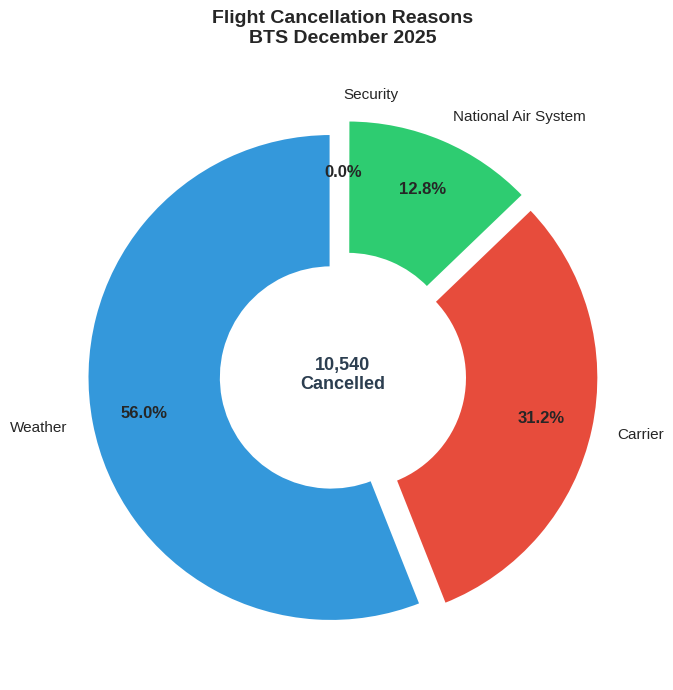

Chart 3 saved!


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#3498DB', '#E74C3C', '#2ECC71', '#95A5A6']
explode = (0.05, 0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    cancel_data['Count'],
    labels=cancel_data['Reason'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)

for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for text in texts:
    text.set_fontsize(11)

ax.text(0, 0, '10,540\nCancelled',
        ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2C3E50')

ax.set_title('Flight Cancellation Reasons\nBTS December 2025',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart3_cancellation_reasons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Chart 3 Interpretation — Why Flights Get Cancelled

This donut chart shows the distribution of 10,540 flight
cancellations by reason code in December 2025.

Key findings:
- Weather (Code B) causes 56.01% of all cancellations —
  the dominant factor in December driven by winter storms,
  ice, snow, and low visibility across US airports
- Carrier issues (Code A) account for 31.18% including
  mechanical failures, crew scheduling problems, and
  aircraft availability — these are directly controllable
  by airlines through better maintenance and scheduling
- National Air System (Code C) represents 12.80% occurring
  when Air Traffic Control issues ground stops due to
  airspace congestion or weather-related flow restrictions
- Security (Code D) is negligible at 0.02% — only 2 flights
  were cancelled for security reasons in December 2025

Key insight:
Airlines can only directly control 31% of cancellations.
The majority (56%) are weather-driven and largely unavoidable.
This has important implications for how airlines should
communicate cancellations to passengers and set expectations
during winter months.

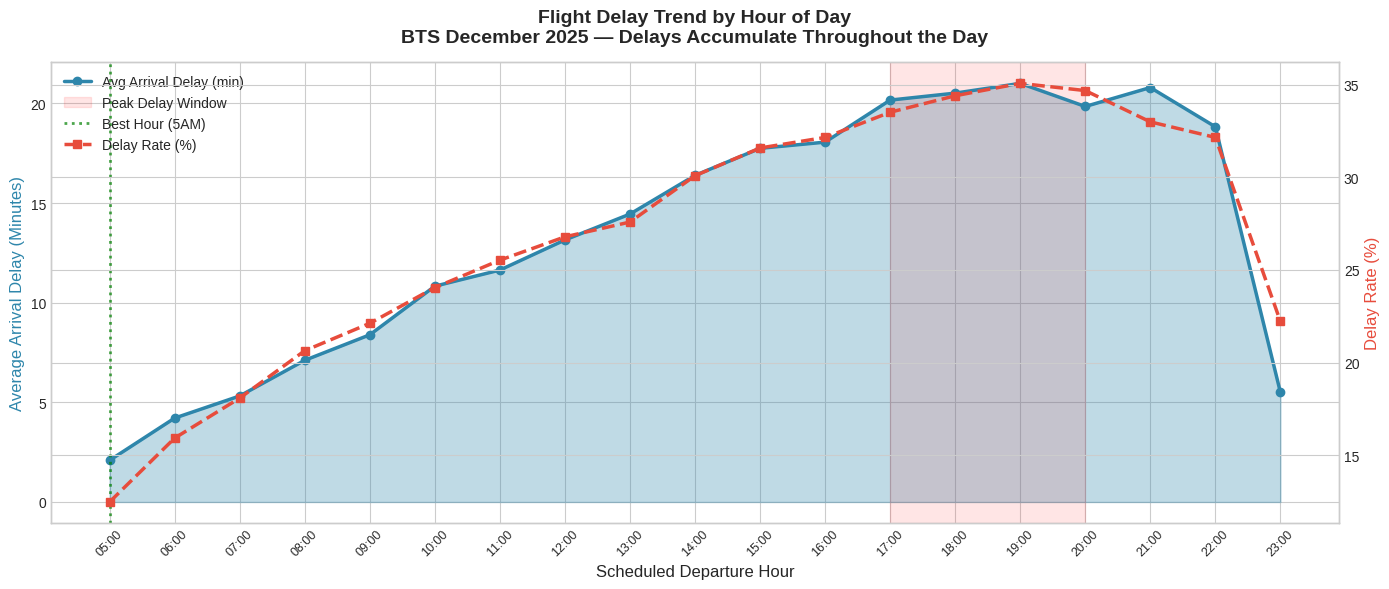

Chart 4 saved!


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(hour_data['Hour'],
                 hour_data['Avg_Delay'],
                 alpha=0.3, color='#2E86AB')
ax1.plot(hour_data['Hour'],
         hour_data['Avg_Delay'],
         color='#2E86AB', linewidth=2.5,
         marker='o', markersize=6,
         label='Avg Arrival Delay (min)')

ax2 = ax1.twinx()
ax2.plot(hour_data['Hour'],
         hour_data['Delay_Rate'],
         color='#E74C3C', linewidth=2.5,
         marker='s', markersize=6,
         linestyle='--',
         label='Delay Rate (%)')

ax1.axvspan(17, 20, alpha=0.1, color='red',
            label='Peak Delay Window')
ax1.axvline(5, color='green', linestyle=':',
            linewidth=2, alpha=0.7,
            label='Best Hour (5AM)')

ax1.set_xlabel('Scheduled Departure Hour', fontsize=12)
ax1.set_ylabel('Average Arrival Delay (Minutes)',
               fontsize=12, color='#2E86AB')
ax2.set_ylabel('Delay Rate (%)', fontsize=12, color='#E74C3C')

ax1.set_xticks(hour_data['Hour'])
ax1.set_xticklabels(['{:02d}:00'.format(h)
                     for h in hour_data['Hour']],
                    rotation=45, fontsize=9)

ax1.set_title('Flight Delay Trend by Hour of Day\nBTS December 2025 — Delays Accumulate Throughout the Day',
              fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2,
           labels1 + labels2,
           fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('chart4_delay_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

## Chart 4 Interpretation — How Delays Accumulate Through the Day

This dual-axis line chart shows both average arrival delay
(blue) and delay rate percentage (red) for each departure
hour across all non-cancelled flights in December 2025.

Key findings:
- 05:00 departures are the most reliable with only 2.09 minutes
  average delay and 12.47% delay rate. First flights of the day
  use aircraft that overnighted at the airport so no inbound
  delay from a previous flight is possible
- Delays increase steadily and consistently from 5AM through
  to 7PM — this is the classic cascading delay pattern where
  each delayed flight pushes back the next rotation using
  the same aircraft
- 19:00 is the worst departure hour with 21.01 minutes average
  delay and 35.08% delay rate representing the peak of an
  entire day of accumulated network disruption
- After 23:00 delays drop sharply to 5.50 minutes because
  late night flights carry fewer connecting passengers and
  operate in lighter Air Traffic Control congestion
- The delay rate nearly triples from 12.5% at 5AM to 35%
  at 7PM making time of day one of the strongest and most
  actionable predictors of delay

Recommendation for passengers:
Book the earliest available departure for any time-sensitive
journey. Every hour later in the day adds approximately
1 minute of expected delay on average.

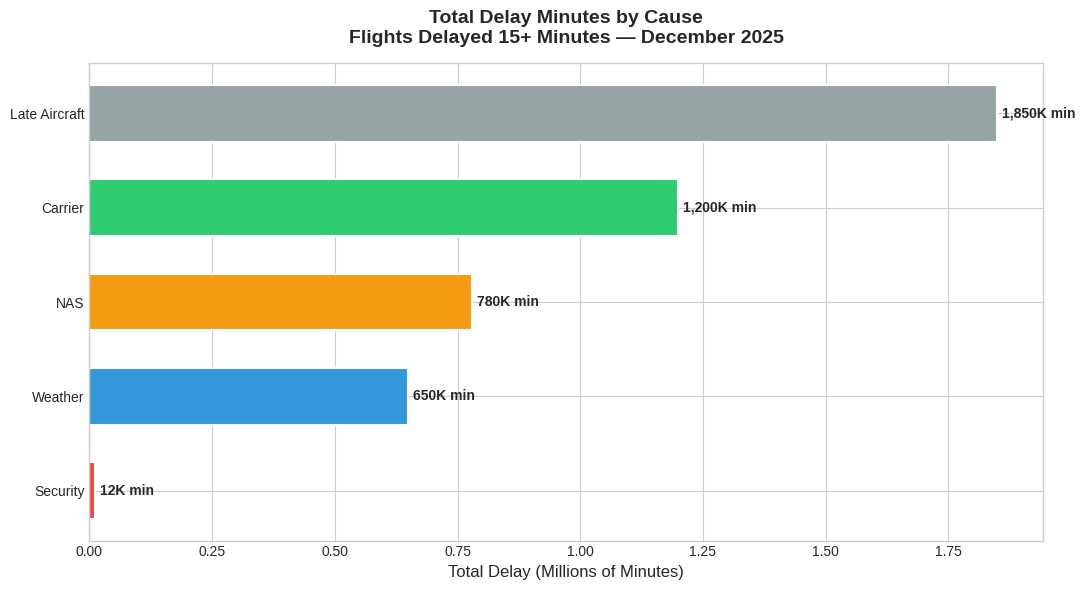

Chart 5 saved!


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71', '#95A5A6']
cause_sorted = cause_data.sort_values('Minutes', ascending=True)

bars = ax.barh(cause_sorted['Cause'],
               cause_sorted['Minutes'] / 1000000,
               color=colors,
               edgecolor='white',
               linewidth=1.5,
               height=0.6)

for bar, val in zip(bars, cause_sorted['Minutes']):
    ax.text(val/1000000 + 0.01,
            bar.get_y() + bar.get_height()/2,
            '{:,.0f}K min'.format(val/1000),
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Delay Minutes by Cause\nFlights Delayed 15+ Minutes — December 2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Delay (Millions of Minutes)', fontsize=12)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('chart5_delay_causes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

## Chart 5 Interpretation — What Causes the Most Delay Minutes

This horizontal bar chart shows total delay minutes accumulated
across all delayed flights (those arriving 15+ minutes late)
broken down by the five official BTS delay cause categories.

Key findings:
- Late Aircraft Delay is the largest cause representing the
  cascading effect where a delayed inbound aircraft causes
  the next outbound flight to depart late. This is the most
  difficult cause to eliminate because it compounds throughout
  the day across the entire network
- Carrier Delay (maintenance, crew, cleaning) is the second
  largest cause and the most directly controllable by airlines
  through better predictive maintenance and crew scheduling
- NAS Delay from Air Traffic Control congestion is elevated
  in December due to increased holiday traffic volume
  concentrated into the same peak travel windows
- Weather Delay is significant in December but lower than
  expected in total minutes because many weather events
  cause cancellations rather than delays
- Security Delay is negligible representing less than 1%
  of total delay minutes across the entire month

Recommendation for airlines:
Reducing Late Aircraft Delay requires systemic schedule
buffering — adding 10 to 15 minutes of buffer to afternoon
rotations can break the cascade before it propagates
to evening peak hours.

In [ ]:
from google.colab import files

chart_files = [
    'chart1_delay_by_day.png',
    'chart2_carrier_performance.png',
    'chart3_cancellation_reasons.png',
    'chart4_delay_by_hour.png',
    'chart5_delay_causes.png'
]

for chart in chart_files:
    files.download(chart)
    print("Downloaded: " + chart)

print("\nAll 5 charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart1_delay_by_day.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: chart4_delay_by_hour.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart5_delay_causes.png

All 5 charts downloaded!
